In [ ]:
import pandas as pd
import numpy as np

# Carregamento dos dados
df = pd.read_csv("brasileirao.csv")

# Resultado da partida (quem venceu)
df["resultado"] = np.where(
    df["gols_mandante"] > df["gols_visitante"], "Mandante",
    np.where(
        df["gols_mandante"] < df["gols_visitante"], "Visitante",
        "Empate"
    )
)

# Total de gols na partida (indicador de jogos mais ofensivos)
df["total_gols"] = df["gols_mandante"] + df["gols_visitante"]

# Saldo de gols do mandante (força relativa no jogo)
df["saldo_mandante"] = df["gols_mandante"] - df["gols_visitante"]

# Indicador binário de vitória do mandante (útil para médias e modelos)
df["vitoria_mandante"] = (df["resultado"] == "Mandante").astype(int)

In [3]:
gols_por_ano = (
    df.groupby("ano_campeonato")
    .agg(
        media_gols=("total_gols", "mean"),
        mediana_gols=("total_gols", "median"),
        max_gols=("total_gols", "max"),
        jogos=("total_gols", "count")
    )
    .reset_index()
    .sort_values("ano_campeonato")
)

In [4]:
distribuicao_resultados = (
    df["resultado"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percentual")
    .reset_index()
    .rename(columns={"index": "resultado"})
)

In [5]:
df["eficiencia_visitante"] = np.where(
    df["chutes_visitante"] > 0,
    df["gols_visitante"] / df["chutes_visitante"],
    0
)

In [6]:
defesas_por_time = (
    df.groupby("time_mandante")
    .agg(
        media_defesas=("defesas_mandante", "mean"),
        media_chutes_sofridos=("chutes_visitante", "mean"),
        jogos=("defesas_mandante", "count")
    )
    .sort_values("media_defesas", ascending=False)
    .reset_index()
)

In [7]:
df["vitoria_mandante"] = (df["resultado"] == "Mandante").astype(int)

In [8]:
df.groupby("resultado")["publico"].mean()

resultado
Empate       15824.958632
Mandante     17063.602177
Visitante    14815.305367
Name: publico, dtype: float64

In [9]:
df["pressao_mandante"] = (
    df["chutes_mandante"] +
    df["escanteios_mandante"] +
    df["chutes_bola_parada_mandante"]
)

In [10]:
df["venceu_1t"] = (
    df["gols_1_tempo_mandante"] > df["gols_1_tempo_visitante"]
).astype(int)

In [11]:
df.head()

,ano_campeonato,data,rodada,estadio,arbitro,publico,publico_max,time_mandante,time_visitante,tecnico_mandante,...,chutes_visitante,chutes_fora_mandante,chutes_fora_visitante,resultado,total_gols,saldo_mandante,vitoria_mandante,eficiencia_visitante,pressao_mandante,venceu_1t
0,2024,6/30/2024,13,Estádio Francisco Stédile,Paulo Cesar Zanovelli,16221.0,30822.0,Grêmio,Fluminense,Renato Gaúcho,...,NaN,NaN,NaN,Mandante,1.0,1.0,1,0.0,NaN,0
1,2024,7/5/2024,14,Estádio Francisco Stédile,Marcelo de Lima Henrique,20797.0,30540.0,Grêmio,Palmeiras,Renato Gaúcho,...,NaN,NaN,NaN,Empate,4.0,0.0,0,0.0,NaN,1
2,2024,7/10/2024,16,Estádio Francisco Stédile,Bruno Arleu de Araújo,4623.0,30822.0,Grêmio,Cruzeiro,Renato Gaúcho,...,NaN,NaN,NaN,Visitante,2.0,-2.0,0,0.0,NaN,0
3,2024,7/21/2024,18,Estádio Francisco Stédile,Savio Pereira Sampaio,25248.0,30540.0,Grêmio,EC Vitória,Renato Gaúcho,...,NaN,NaN,NaN,Mandante,2.0,2.0,1,0.0,NaN,0
4,2024,7/29/2024,20,Arena Condá,Paulo Cesar Zanovelli,17621.0,22540.0,Grêmio,Vasco da Gama,Renato Gaúcho,...,NaN,NaN,NaN,Mandante,1.0,1.0,1,0.0,NaN,0


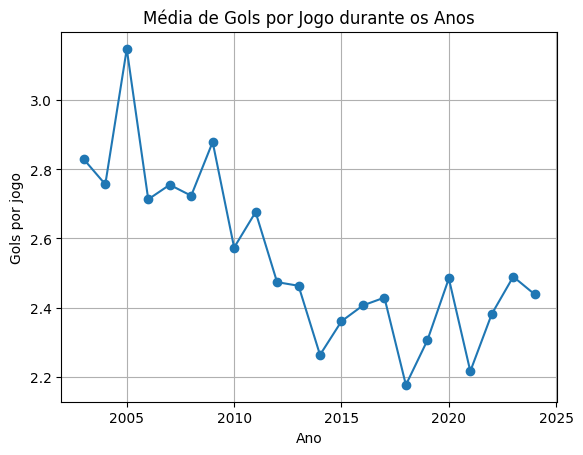

In [14]:
import matplotlib.pyplot as plt
gols_ano = (
    df.groupby("ano_campeonato")["total_gols"]
    .mean()
    .sort_index()
)

plt.figure()

plt.plot(gols_ano.index, gols_ano.values, marker='o')

plt.title("Média de Gols por Jogo durante os Anos")
plt.xlabel("Ano")
plt.ylabel("Gols por jogo")

plt.grid()

plt.show()

In [13]:
df["resultado"].value_counts(normalize=True) * 100

resultado
Mandante     49.473560
Empate       26.605939
Visitante    23.920502
Name: proportion, dtype: float64

Vantagem de jogar em casa

Os dados revelam uma vantagem significativa para equipes mandantes no Brasileirão. Enquanto 49,47% das partidas resultam em vitória do time da casa, apenas 23,92% são vencidas pelos visitantes, além de 26,61% de empates.

Essa diferença expressiva sugere que fatores associados ao mando de campo — como apoio da torcida, familiaridade com o estádio e possíveis influências logísticas — exercem impacto relevante nos resultados, tornando o fator casa uma variável importante na análise de desempenho e previsões de partidas.

In [13]:
df["mais_chutes_mandante"] = df["chutes_mandante"] > df["chutes_visitante"]

pd.crosstab(df["mais_chutes_mandante"], df["resultado"], normalize="index")

resultado,Empate,Mandante,Visitante
mais_chutes_mandante,,,
False,0.262892,0.493414,0.243694
True,0.283219,0.501898,0.214882


In [10]:
df["mais_caro_mandante"] = df["valor_equipe_titular_mandante"] > df["valor_equipe_titular_visitante"]

pd.crosstab(df["mais_caro_mandante"], df["resultado"], normalize="index")

resultado,Empate,Mandante,Visitante
mais_caro_mandante,,,
False,0.277820,0.436954,0.285226
True,0.246627,0.590210,0.163163


💰⚽ Impacto do valor de elenco no desempenho

Os dados revelam que o valor de mercado do elenco está associado a um aumento substancial na probabilidade de vitória. Equipes mandantes com menor valor apresentam taxa de vitória de 43,7%, enquanto aquelas com maior valor atingem 59,0%, representando um ganho de cerca de 15 pontos percentuais.

Além disso, observa-se uma redução nas vitórias dos visitantes (28,52% → 16,32%) quando o mandante é mais valioso, reforçando o impacto competitivo do investimento.

Esses resultados sugerem que, embora o futebol envolva variabilidade e fatores táticos, o poder financeiro do elenco constitui um dos principais determinantes do desempenho em campo.

In [15]:
df["eficiencia_mandante"].mean()
df["eficiencia_mandante"].describe()

c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    2083.000000
mean             inf
std              NaN
min         0.000000
25%         0.041667
50%         0.100000
75%         0.181818
max              inf
Name: eficiencia_mandante, dtype: float64

In [16]:
df["ganhou_1t"] = df["gols_1_tempo_mandante"] > df["gols_1_tempo_visitante"]

pd.crosstab(df["ganhou_1t"], df["resultado"], normalize="index")

resultado,Empate,Mandante,Visitante
ganhou_1t,,,
False,0.310322,0.376548,0.313130
True,0.154295,0.793161,0.052544


🧠 O primeiro tempo como determinante do resultado

Os dados indicam que o desempenho no primeiro tempo é um dos principais fatores associados ao resultado final das partidas. Equipes que encerram a primeira etapa em vantagem apresentam uma probabilidade de vitória de aproximadamente 79,3%, enquanto a taxa de virada por parte dos visitantes é bastante reduzida (5,25%).

Em contraste, quando o mandante não lidera no intervalo, o jogo se torna consideravelmente mais aberto, com probabilidades de vitória mais equilibradas (cerca de 37% para o mandante e 31% para o visitante).

Esses resultados sugerem que a vantagem inicial não apenas aumenta significativamente a chance de vitória, mas também reduz a variabilidade do resultado, destacando a importância estratégica do primeiro tempo.

In [17]:
df.groupby("resultado")["publico"].mean()

resultado
Empate       15824.958632
Mandante     17063.602177
Visitante    14815.305367
Name: publico, dtype: float64

🏟️📊 Público e desempenho das equipes

Observa-se que partidas com maior público estão associadas a uma maior taxa de vitórias dos mandantes. Em média, jogos vencidos pelo time da casa contam com aproximadamente 17.063 torcedores, número superior ao observado em empates (15.825) e vitórias dos visitantes (14.815).

Embora essa diferença sugira que o apoio da torcida possa influenciar positivamente o desempenho das equipes mandantes, é importante considerar possíveis fatores de confusão — como a presença de times mais populares ou jogos de maior relevância — que também podem impactar simultaneamente o público e o resultado.

Dessa forma, os resultados indicam uma correlação positiva, mas não permitem afirmar causalidade direta.

In [12]:
import numpy as np

# remover NaN e infinitos
df_clean = df[["chutes_mandante", "gols_mandante"]].replace([np.inf, -np.inf], np.nan).dropna()

x = df_clean["chutes_mandante"]
y = df_clean["gols_mandante"]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

In [21]:
df.groupby("time_mandante")["vitoria_mandante"].mean().sort_values(ascending=False)

time_mandante
Grêmio            0.590426
Internacional     0.584184
Palmeiras         0.578667
São Paulo         0.572464
Atlético-PR       0.557252
Santos FC         0.556391
Atlético-MG       0.555838
Flamengo          0.548309
Paysandu SC       0.543860
Corinthians       0.535533
Cruzeiro          0.532213
Fluminense        0.501211
Fortaleza         0.479042
Ipatinga FC       0.473684
São Caetano       0.473684
Paraná            0.473684
RB Bragantino     0.471910
Botafogo          0.469101
Ponte Preta       0.467836
Coritiba FC       0.466667
Criciúma EC       0.466667
Sport Recife      0.464115
Goiás EC          0.461538
Guarani           0.456140
Vasco da Gama     0.446541
EC Vitória        0.443902
Náutico           0.442105
EC Bahia          0.430493
Santo André       0.421053
Portuguesa        0.421053
Figueirense FC    0.411483
Juventude         0.408163
América-MG        0.394737
Barueri           0.394737
Ceará SC          0.390977
Chapecoense       0.360902
Santa Cruz    

In [20]:
df["time_mandante"] = df["time_mandante"].replace({
    "Athletico-PR": "Atlético-PR",
    "Santos": "Santos FC",
    "Goiás": "Goiás EC"
})

🏠📊 Eficiência no uso do mando de campo

Os dados mostram que determinados clubes apresentam desempenho superior como mandantes, com destaque para Grêmio (59,0%), Internacional (58,4%) e Palmeiras (57,9%). Essas equipes mantêm taxas de vitória em casa significativamente acima da média do campeonato, evidenciando maior eficiência na exploração do fator local.

Essa consistência sugere que o mando de campo não impacta todas as equipes de forma uniforme, mas sim atua como uma vantagem competitiva que pode ser melhor aproveitada por clubes com maior estabilidade de desempenho ao longo do tempo.

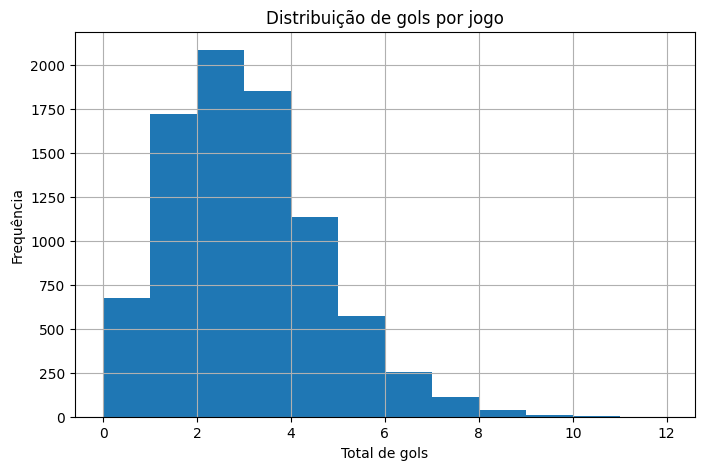

In [13]:
import matplotlib.pyplot as plt

gols = df["total_gols"].dropna()

plt.figure(figsize=(8, 5))

plt.hist(gols, bins=range(0, int(gols.max()) + 2))

plt.title("Distribuição de gols por jogo")
plt.xlabel("Total de gols")
plt.ylabel("Frequência")

plt.grid()

plt.show()

In [15]:
publico_ano = (
    df.groupby("ano_campeonato")["publico"]
    .mean()
    .sort_index()
)

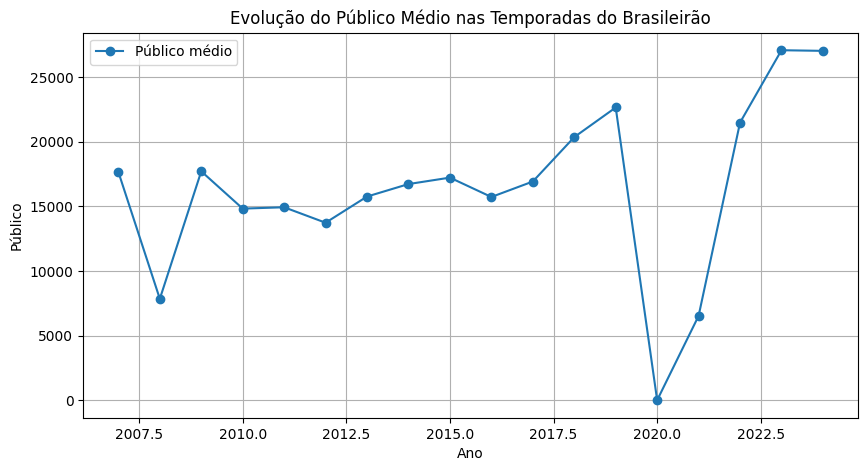

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# garantir ordenação
publico_ano = publico_ano.sort_index()

x = publico_ano.index.values
y = publico_ano.values

# regressão
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(10, 5))

# dados reais
plt.plot(x, y, marker='o', label="Público médio")


plt.legend()
plt.title("Evolução do Público Médio nas Temporadas do Brasileirão")
plt.xlabel("Ano")
plt.ylabel("Público")

plt.grid()
plt.show()

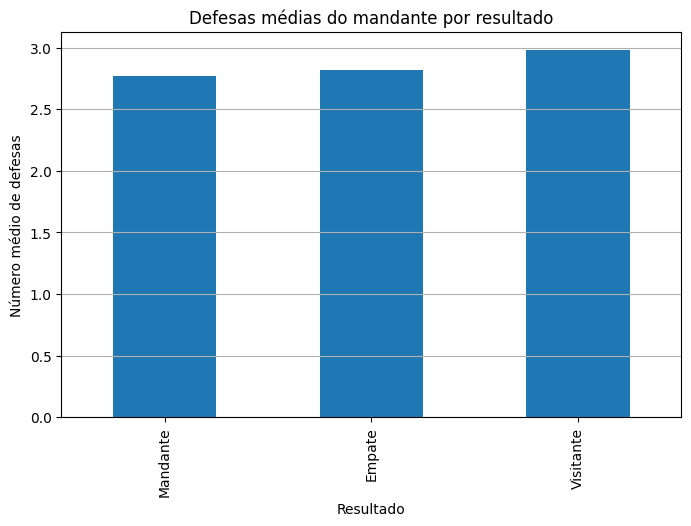

In [21]:
import matplotlib.pyplot as plt

defesas = (
    df.groupby("resultado")["defesas_mandante"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))

defesas.plot(kind="bar")

plt.title("Defesas médias do mandante por resultado")
plt.xlabel("Resultado")
plt.ylabel("Número médio de defesas")

plt.grid(axis="y")

plt.show()

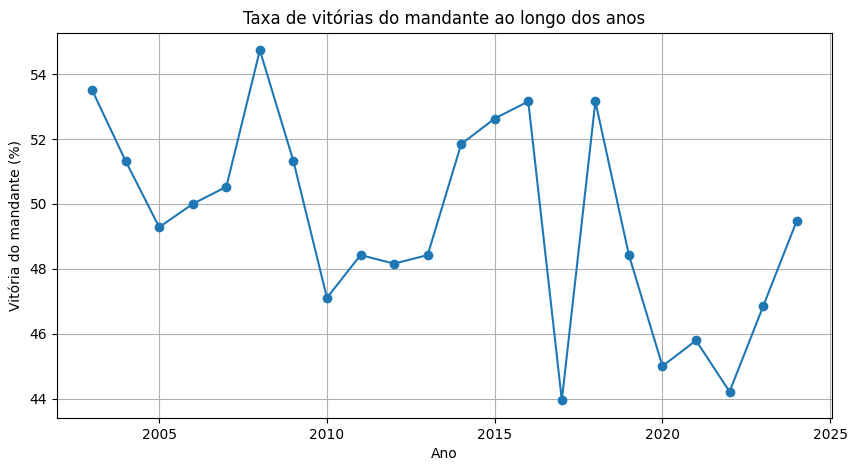

In [22]:
vantagem_ano = pd.crosstab(
    df["ano_campeonato"],
    df["resultado"],
    normalize="index"
).sort_index()

plt.figure(figsize=(10, 5))

plt.plot(
    vantagem_ano.index,
    vantagem_ano["Mandante"] * 100,  # corrigindo pra %
    marker='o'
)

plt.title("Taxa de vitórias do mandante ao longo dos anos")
plt.xlabel("Ano")
plt.ylabel("Vitória do mandante (%)")

plt.grid()

plt.show()

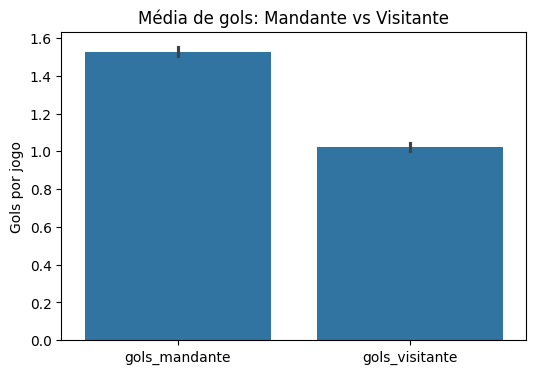

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

df_melt = df.melt(
    value_vars=["gols_mandante", "gols_visitante"],
    var_name="tipo",
    value_name="gols"
)

plt.figure(figsize=(6, 4))

sns.barplot(data=df_melt, x="tipo", y="gols")

plt.title("Média de gols: Mandante vs Visitante")
plt.xlabel("")
plt.ylabel("Gols por jogo")

plt.show()

💡 Insight:

Times da casa fazem mais gols → reforça vantagem de casa

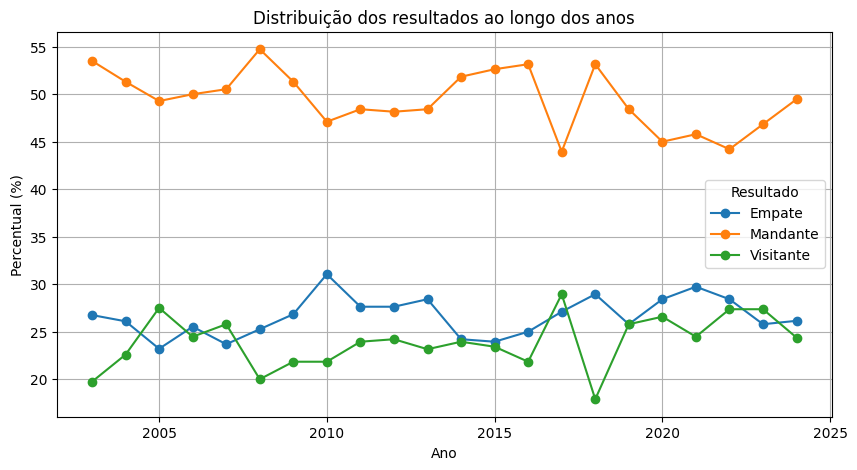

In [25]:
resultado_ano = (
    pd.crosstab(
        df["ano_campeonato"],
        df["resultado"],
        normalize="index"
    )
    .sort_index()
)

plt.figure(figsize=(10, 5))

for col in resultado_ano.columns:
    plt.plot(
        resultado_ano.index,
        resultado_ano[col] * 100,  # convertendo pra %
        marker='o',
        label=col
    )

plt.title("Distribuição dos resultados ao longo dos anos")
plt.xlabel("Ano")
plt.ylabel("Percentual (%)")

plt.legend(title="Resultado")
plt.grid()

plt.show()

⚽📊 Evolução da média de gols no Brasileirão

A média de gols no Brasileirão ao longo da era dos pontos corridos apresenta um comportamento não linear: após um período inicial de alta, observa-se uma queda significativa, seguida por uma fase recente de recuperação e relativa estabilidade.

Para compreender essa dinâmica, é possível dividir o período em três fases principais:

1. A “Era do Ataque” (2003–2005)

Nos primeiros anos do formato de pontos corridos, a média de gols foi excepcionalmente elevada. Esse cenário pode ser explicado por dois fatores principais: o maior número de equipes participantes (24 em 2003 e 2004; 22 em 2005) e um menor grau de organização tática defensiva.

Pico histórico: 2005 registrou a maior média da série, com 3,13 gols por jogo
Destaque ofensivo: o Santos de 2004 marcou 103 gols, recorde da era

Esse período foi marcado por jogos mais abertos e maior volume ofensivo.

2. A “Era da Consolidação Defensiva” (2006–2018)

Com a redução para 20 clubes e a evolução das estratégias táticas, especialmente no aspecto defensivo, houve uma queda consistente na média de gols.

Mínimo histórico: 2018 apresentou a menor média, com 2,18 gols por jogo

Nesse intervalo, o campeonato se caracterizou por:

maior equilíbrio competitivo
maior organização defensiva
valorização de resultados mínimos (ex: 1–0)
3. A Retomada Ofensiva (2019–2025)

A partir de 2019, observa-se uma retomada gradual da média de gols, possivelmente associada a mudanças no perfil tático das equipes, incluindo maior intensidade ofensiva e novas abordagens estratégicas.

2023: melhor desempenho ofensivo da última década
2024: manutenção da tendência de alta (2,44 gols/jogo)
2025: consolidação da recuperação (2,52 gols/jogo, entre as maiores médias da era)

Esse período sugere uma revalorização do jogo ofensivo, sem retorno aos níveis extremos do início dos anos 2000.

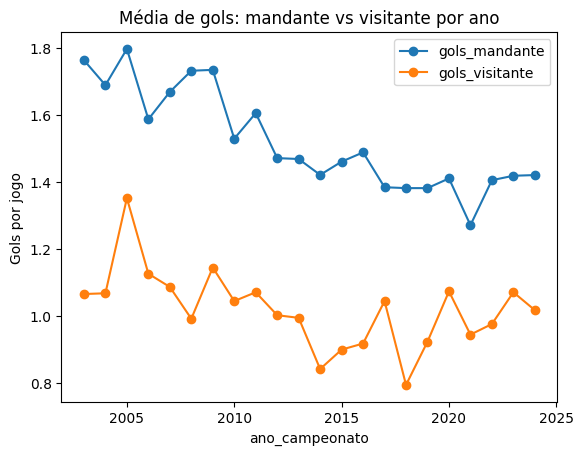

In [28]:
gols_ano = df.groupby("ano_campeonato")[["gols_mandante", "gols_visitante"]].mean()

gols_ano.plot(marker="o")

plt.title("Média de gols: mandante vs visitante por ano")
plt.ylabel("Gols por jogo")

plt.show()

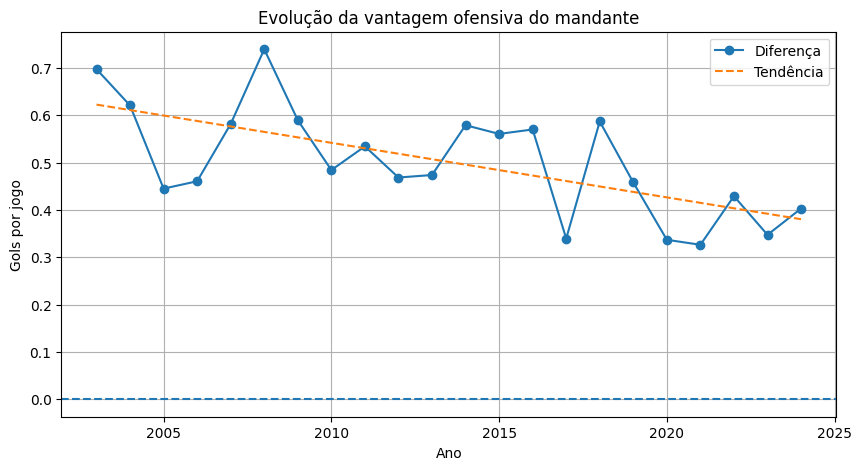

In [30]:
import numpy as np

x = gols_ano.index.values
y = gols_ano["dif"].values

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(10, 5))

plt.plot(x, y, marker="o", label="Diferença")
plt.plot(x, p(x), linestyle="--", label="Tendência")

plt.axhline(0, linestyle="--")

plt.legend()
plt.title("Evolução da vantagem ofensiva do mandante")
plt.xlabel("Ano")
plt.ylabel("Gols por jogo")

plt.grid()
plt.show()

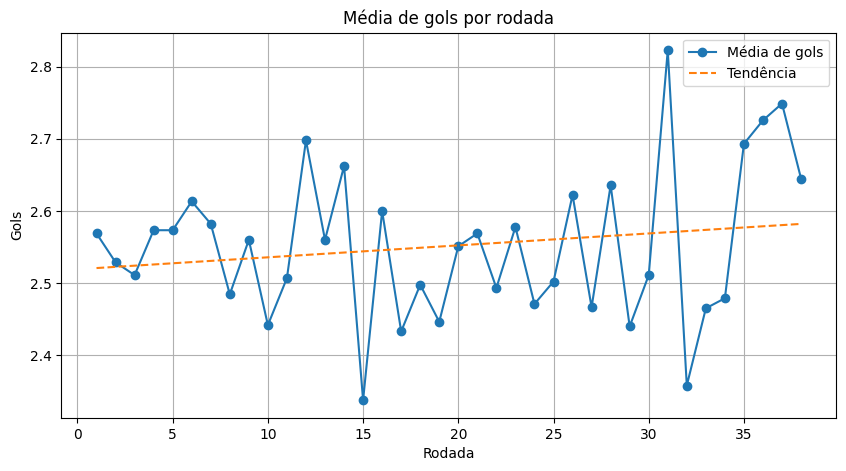

In [32]:
import numpy as np
import matplotlib.pyplot as plt

gols_rodada = (
    df.groupby("rodada")["total_gols"]
    .mean()
    .sort_index()
)

x = gols_rodada.index.values
y = gols_rodada.values

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(10, 5))

plt.plot(x, y, marker="o", label="Média de gols")
plt.plot(x, p(x), linestyle="--", label="Tendência")

plt.legend()
plt.title("Média de gols por rodada")
plt.xlabel("Rodada")
plt.ylabel("Gols")

plt.grid()
plt.show()

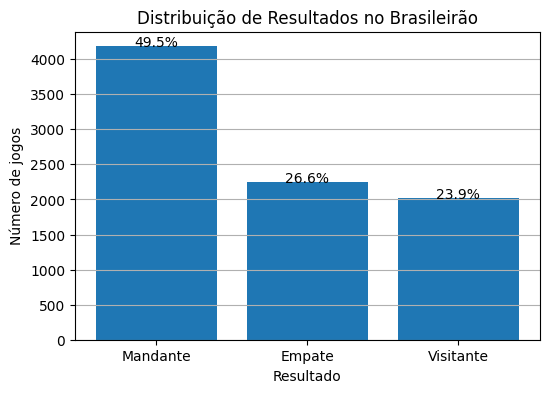

In [15]:
import matplotlib.pyplot as plt

contagem = df["resultado"].value_counts()
percentual = df["resultado"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))

bars = plt.bar(contagem.index, contagem.values)


for i, v in enumerate(contagem.values):
    plt.text(i, v, f"{percentual.iloc[i]:.1f}%", ha='center')

plt.title("Distribuição de Resultados no Brasileirão")
plt.xlabel("Resultado")
plt.ylabel("Número de jogos")

plt.grid(axis="y")

plt.show()

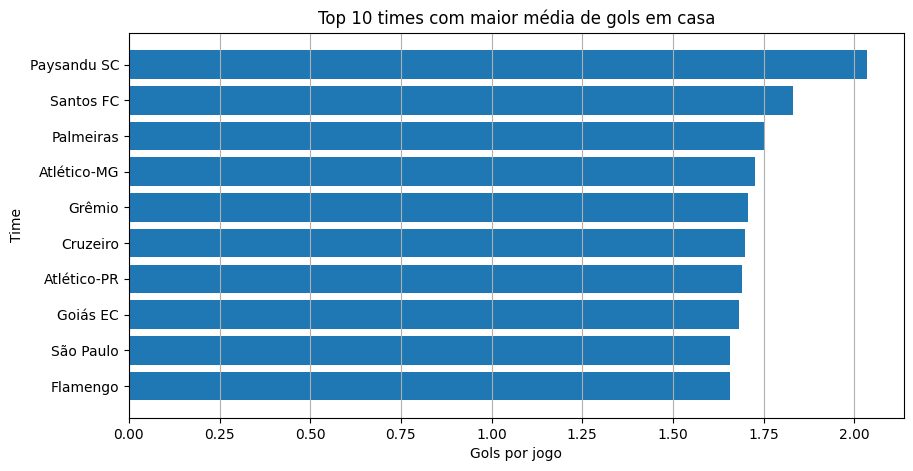

In [36]:
import matplotlib.pyplot as plt

top_gols = (
    df.groupby("time_mandante")
    .agg(
        media_gols=("gols_mandante", "mean"),
        jogos=("gols_mandante", "count")
    )
    .query("jogos >= 10")
    .sort_values("media_gols", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))

plt.barh(top_gols.index, top_gols["media_gols"])
plt.gca().invert_yaxis()

plt.title("Top 10 times com maior média de gols em casa")
plt.xlabel("Gols por jogo")
plt.ylabel("Time")

plt.grid(axis="x")

plt.show()

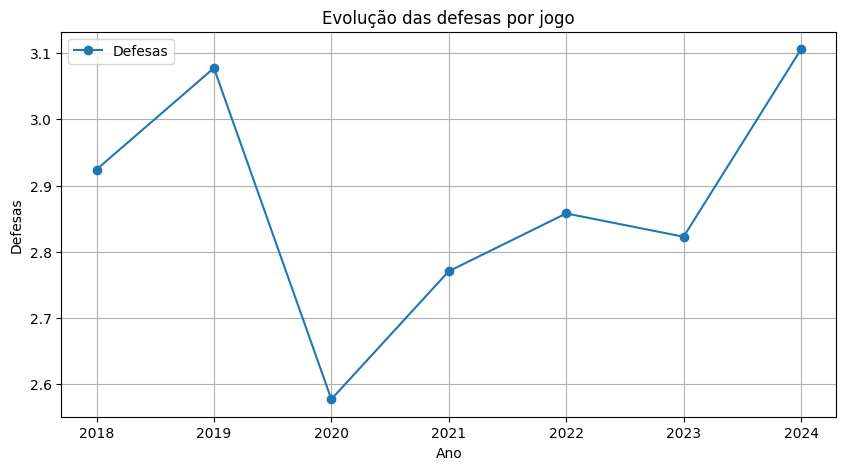

In [39]:
import numpy as np
import matplotlib.pyplot as plt

defesas_ano = (
    df.groupby("ano_campeonato")["defesas_mandante"]
    .mean()
    .sort_index()
)

x = defesas_ano.index.values
y = defesas_ano.values

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(10, 5))

plt.plot(x, y, marker="o", label="Defesas")

plt.legend()
plt.title("Evolução das defesas por jogo")
plt.xlabel("Ano")
plt.ylabel("Defesas")

plt.grid()
plt.show()

In [67]:
df_filtrado = df[df["ano_campeonato"] <= 2021]

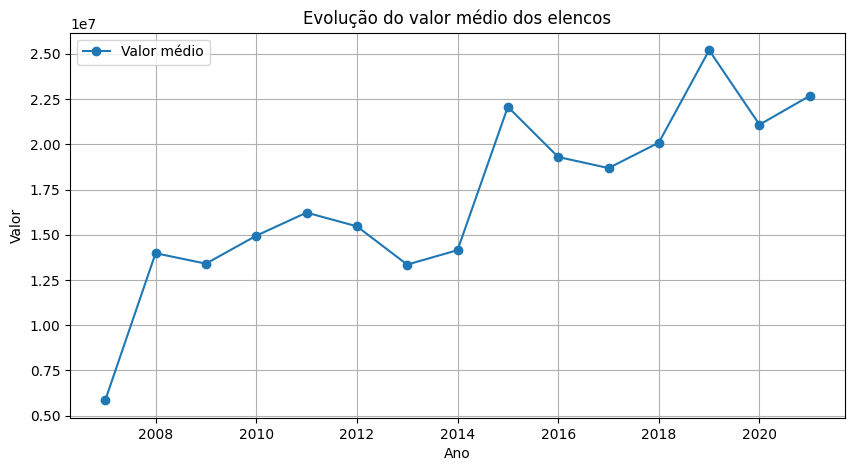

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# garantir o filtro
df_filtrado = df[df["ano_campeonato"] <= 2021]

# criar a variável
valor_ano = (
    df_filtrado.groupby("ano_campeonato")["valor_equipe_titular_mandante"]
    .mean()
    .sort_index()
)

# regressão
x = valor_ano.index.values
y = valor_ano.values

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# gráfico
plt.figure(figsize=(10, 5))

plt.plot(x, y, marker="o", label="Valor médio")

plt.legend()
plt.title("Evolução do valor médio dos elencos")
plt.xlabel("Ano")
plt.ylabel("Valor")

plt.grid()
plt.show()

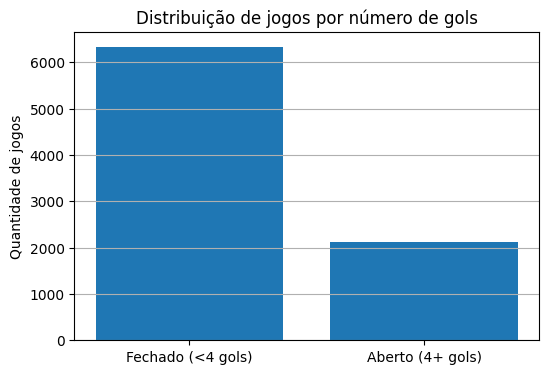

In [43]:
import matplotlib.pyplot as plt

df["jogo_aberto"] = df["total_gols"] >= 4

contagem = df["jogo_aberto"].value_counts()
labels = ["Fechado (<4 gols)", "Aberto (4+ gols)"]

plt.figure(figsize=(6, 4))

plt.bar(labels, contagem.values)

plt.title("Distribuição de jogos por número de gols")
plt.ylabel("Quantidade de jogos")

plt.grid(axis="y")

plt.show()

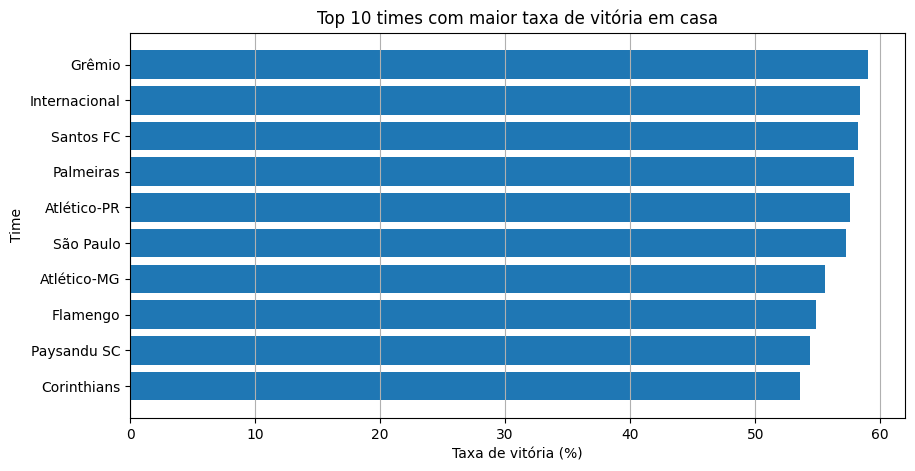

In [45]:
import matplotlib.pyplot as plt

top_vitorias = (
    df.groupby("time_mandante")
    .agg(
        taxa_vitoria=("vitoria_mandante", "mean"),
        jogos=("vitoria_mandante", "count")
    )
    .query("jogos >= 10")
    .sort_values("taxa_vitoria", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))

plt.barh(top_vitorias.index, top_vitorias["taxa_vitoria"] * 100)
plt.gca().invert_yaxis()

plt.title("Top 10 times com maior taxa de vitória em casa")
plt.xlabel("Taxa de vitória (%)")
plt.ylabel("Time")

plt.grid(axis="x")

plt.show()

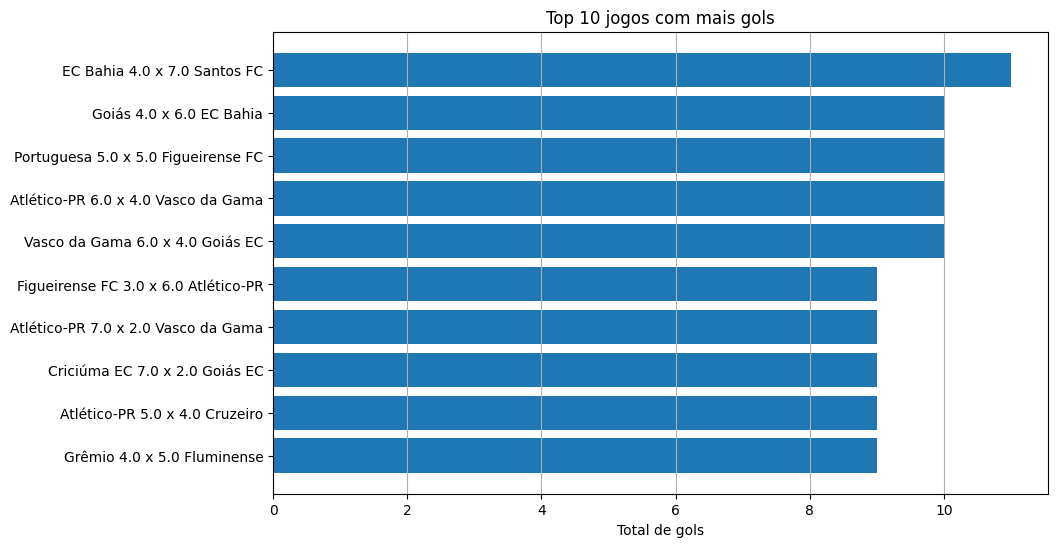

In [46]:
top_jogos = df.sort_values("total_gols", ascending=False).head(10)

labels = (
    top_jogos["time_mandante"] + " " +
    top_jogos["gols_mandante"].astype(str) + " x " +
    top_jogos["gols_visitante"].astype(str) + " " +
    top_jogos["time_visitante"]
)

plt.figure(figsize=(10, 6))

plt.barh(labels, top_jogos["total_gols"])
plt.gca().invert_yaxis()

plt.title("Top 10 jogos com mais gols")
plt.xlabel("Total de gols")

plt.grid(axis="x")

plt.show()

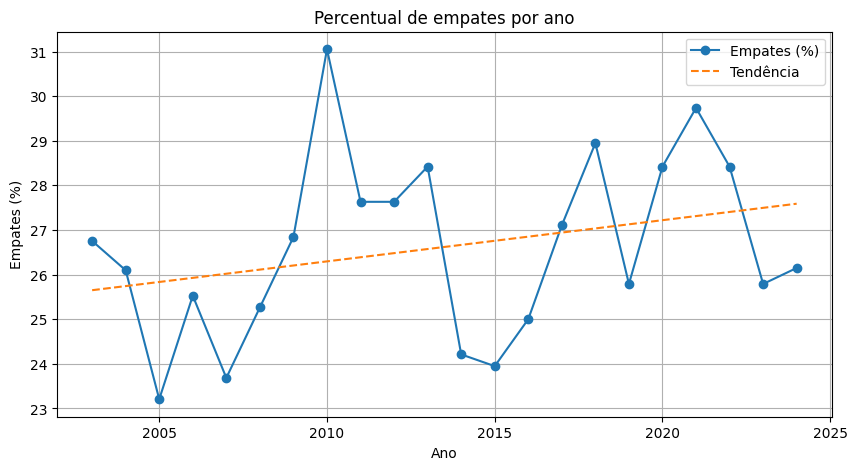

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# criar variável corretamente (proporção)
empates_ano = (
    df.groupby("ano_campeonato")["resultado"]
    .apply(lambda x: (x == "Empate").mean())
    .sort_index()
)

# preparar dados
x = empates_ano.index.values
y = empates_ano.values * 100

# regressão
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# gráfico
plt.figure(figsize=(10, 5))

plt.plot(x, y, marker="o", label="Empates (%)")
plt.plot(x, p(x), linestyle="--", label="Tendência")

plt.title("Percentual de empates por ano")
plt.xlabel("Ano")
plt.ylabel("Empates (%)")

plt.legend()
plt.grid()

plt.show()

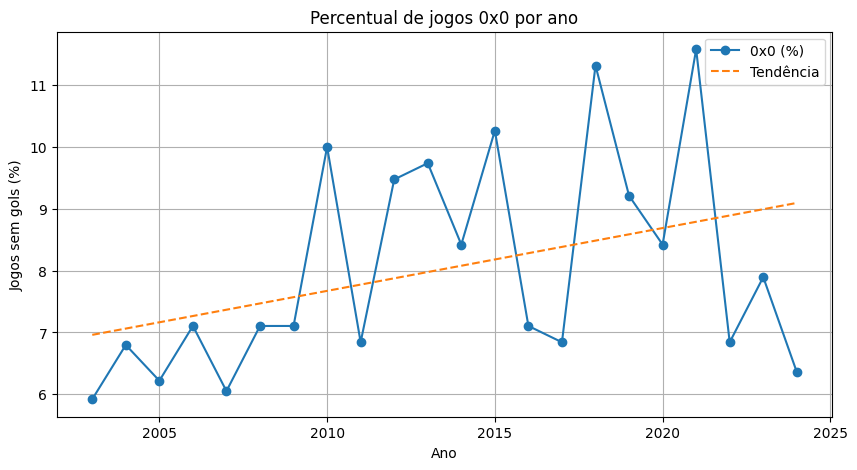

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# criar variável corretamente (proporção)
df["zero_gols"] = df["total_gols"] == 0

zero_ano = (
    df.groupby("ano_campeonato")["zero_gols"]
    .mean()
    .sort_index()
)

# dados
x = zero_ano.index.values
y = zero_ano.values * 100

# tendência
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# gráfico
plt.figure(figsize=(10, 5))

plt.plot(x, y, marker="o", label="0x0 (%)")
plt.plot(x, p(x), linestyle="--", label="Tendência")

plt.title("Percentual de jogos 0x0 por ano")
plt.xlabel("Ano")
plt.ylabel("Jogos sem gols (%)")

plt.legend()
plt.grid()

plt.show()

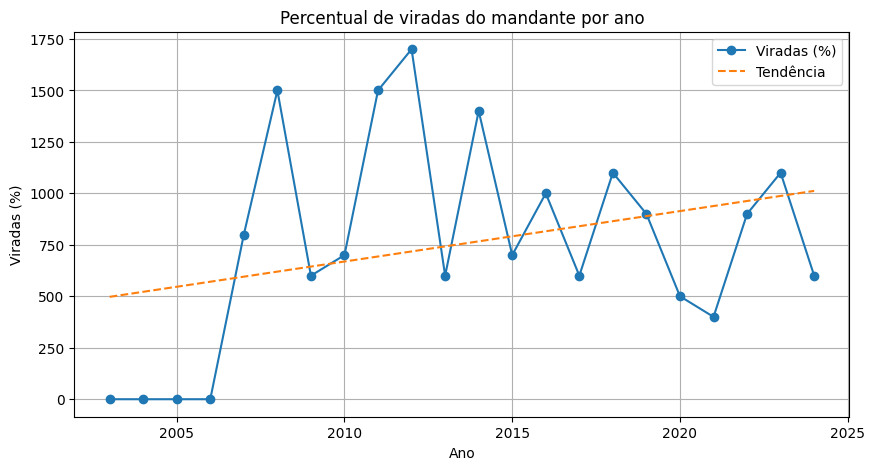

In [52]:
import matplotlib.pyplot as plt
import numpy as np

x = viradas_ano.index.values
y = viradas_ano.values * 100

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(10, 5))

plt.plot(x, y, marker="o", label="Viradas (%)")
plt.plot(x, p(x), linestyle="--", label="Tendência")

plt.title("Percentual de viradas do mandante por ano")
plt.xlabel("Ano")
plt.ylabel("Viradas (%)")

plt.legend()
plt.grid()

plt.show()